In [1]:
!pip install openpyxl

Load the dataset into pandas dataframe format

In [2]:
from google.colab import files
import pandas as pd
import io
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

df.head()

Saving Telco_customer_churn.xlsx to Telco_customer_churn (4).xlsx


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Ratio of no churn and churn

In [3]:
counts = df['Churn Label'].value_counts()
print(counts)
yes = counts['Yes']
no = counts['No']

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


Bar plot to check how contract length affects churn

/tmp/ipykernel_38233/3913253768.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Contract", y="Churn Score", palette="pastel", edgecolor=".3")


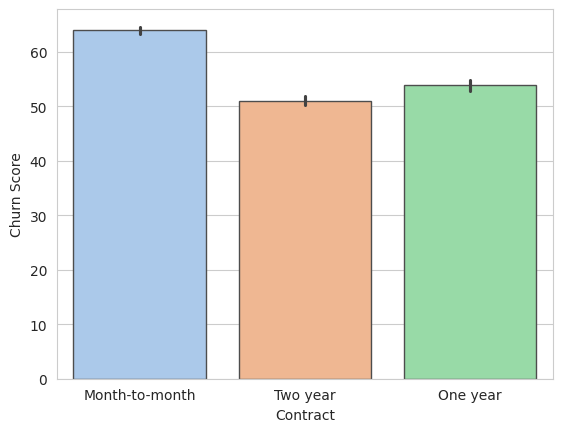

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
sns.barplot(data=df, x="Contract", y="Churn Score", palette="pastel", edgecolor=".3")
plt.show()

* Customers who take shorter subscriptions are more likely to drop the subscription.
* When you have a longer subscription, lower churn may be just due to convenience.

Plotting Churn Label - Number of customers who left v/s didnt leave

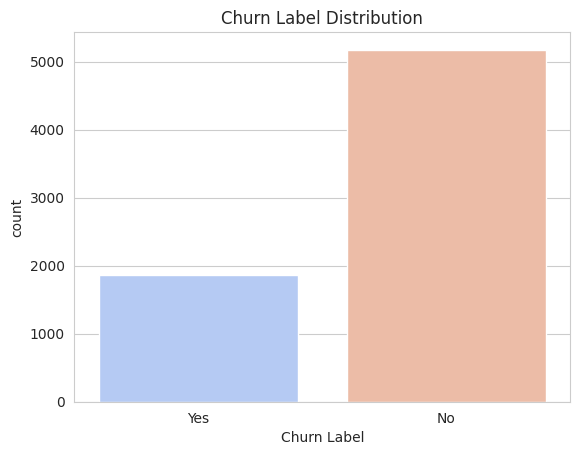

In [6]:
sns.countplot(data=df, x='Churn Label', hue='Churn Label', palette='coolwarm', legend=False)
plt.title('Churn Label Distribution')
plt.show()

Bar plot to check how tenure might affect churn

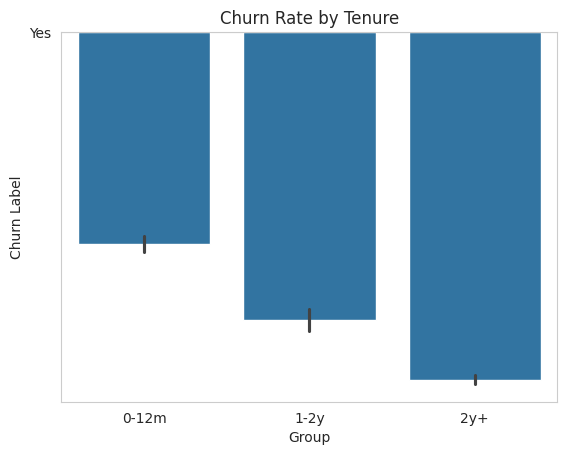

In [5]:
df['Group'] = pd.cut(df['Tenure Months'], bins=[0, 12, 24, 999], labels=['0-12m', '1-2y', '2y+'])
sns.barplot(data=df, x='Group', y='Churn Label', order=['0-12m', '1-2y', '2y+'])
plt.title('Churn Rate by Tenure')
plt.show()



*   Long tenured customers show stronger brand loyalty as they are less likely to cancel
*   Newer customers have highest churn rate, which means they might be exploring different services before committing.


*   Reducing early churn should be a priority.






In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_excel(io.BytesIO(uploaded[filename])) #when it re runs the program it gets the raw data

df['Streaming Movies'] = df['Streaming Movies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['Senior Citizen'] = df['Senior Citizen'].map({'Yes': 1, 'No': 0})
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)
df = df.dropna(subset=['Streaming Movies', 'Senior Citizen', 'Total Charges'])

X = df[['Streaming Movies', 'Senior Citizen', 'Total Charges']]
y = df['Churn Value']

X_scaled = StandardScaler().fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

feature_names = ['Streaming Movies', 'Senior Citizen', 'Total Charges']
print("\nFeature Importance:")
for feature, score in sorted(zip(feature_names, model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feature}: {score:.4f}")

Accuracy: 0.6771

Feature Importance:
  Total Charges: 0.9597
  Senior Citizen: 0.0257
  Streaming Movies: 0.0145



*  Most of the churn seems to be dictated by the pricing. So, the brand should try to make the pricing optimised to their target customers.

*  After the pricing, age influences the churn so the brand should cater to a specific age group to increase profits.



